## Introduction to the EM Algorithm

#### Introduction and Motivation

In this Tutorial, we're going to break down the Expectation-Maximization algorithm — not just in theory, but step by step using a real example with missing data.

You'll see exactly how the EM algorithm helps us estimate parameters when some data points are incomplete — a situation that's surprisingly common in the real world.

First, we’ll walk through just one iteration of the E-step and M-step so you can see the mechanics of how the algorithm fills in missing values and updates estimates.

Then in the second part, we'll show you how the algorithm converges by tracking the log-likelihood, and explain what it's really optimizing.

Whether you’re a data scientist, a researcher, or just EM-curious — you’ll walk away with a clear and intuitive understanding of how the algorithm works and why it’s so powerful.

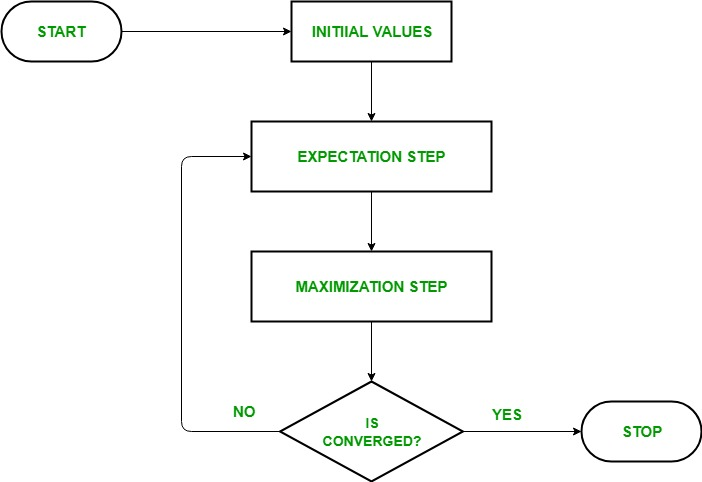

### EM Algorithm: Showing 1 Iteration not maximizing the log likelihood.

```
     Column
       0       1
     ----------------
R 0 | (0,0)  (0,1)
o 1 | (1,0)  (1,1)
w 2 | (2,0)  (2,1)
```



In [1]:
import numpy as np
from numpy.linalg import inv

# Data with one missing value
X = np.array([
    [1.0, 2.0],
    [2.0, np.nan],
    [3.0, 6.0]
])

In [ ]:
X[0,0]

np.float64(1.0)

r,c

In [2]:
X[2,1]

np.float64(6.0)

In [ ]:
X_complete = X[~np.isnan(X).any(axis=1)]
X_complete

array([[1., 2.],
       [3., 6.]])

This line:

Checks each row (axis=1)

If any element in that row is NaN, it returns True

~ inverts that, so we keep only rows without any NaNs

In [ ]:
mu = np.mean(X_complete, axis=0)
mu

array([2., 4.])

Takes the mean of each column

In [ ]:
sigma = np.cov(X_complete, rowvar=False)
sigma

array([[2., 4.],
       [4., 8.]])

rowvar=False means each column is a variable and row is an observation.

In [ ]:
x_obs = X[1, 0]  # Observed part: 2.0
x_obs

np.float64(2.0)

In [ ]:
mu_obs = mu[0]
mu_obs

np.float64(2.0)

#### Its important to see that a value in the second column is missing, so we take the second value.

In [ ]:
mu_miss=mu[1]
mu_miss

np.float64(4.0)

In [ ]:
sigma_oo = sigma[0, 0]    # var(x1)
sigma_om = sigma[0, 1]    # cov(x1, x2)
sigma_mo = sigma[1, 0]    # cov(x2, x1)
sigma_mm = sigma[1, 1]    # var(x2)

In [ ]:
sigma_om

np.float64(4.0)

In [ ]:
sigma_mo

np.float64(4.0)

### 🧠 E-step: Estimating Missing Values with Conditional Expectation

Suppose we have a 2D random vector $X = [X_1, X_2]^T$ drawn from a multivariate normal distribution:

$$
X \sim \mathcal{N}(\mu, \Sigma)
$$

with:

- Mean vector:
  $$
  \mu = \begin{bmatrix} \mu_1 \\ \mu_2 \end{bmatrix}
  $$

- Covariance matrix:
  $$
  \Sigma =
  \begin{bmatrix}
    \sigma_{11} & \sigma_{12} \\
    \sigma_{21} & \sigma_{22}
  \end{bmatrix}
  $$

If we observe $X_1 = x_1$, but $X_2$ is missing, then we estimate the expected value of $X_2$ using the **conditional expectation**:

$$
\mathbb{E}[X_2 \mid X_1 = x_1] =
\mu_2 + \frac{\sigma_{21}}{\sigma_{11}} (x_1 - \mu_1)
$$

In the general multivariate case, the conditional expectation is:

$$
\mathbb{E}[X_{\text{miss}} \mid X_{\text{obs}}] =
\mu_m + \Sigma_{mo} \Sigma_{oo}^{-1} (x_o - \mu_o)
$$

Where:
- $\mu_o$, $\mu_m$ are the means of the observed and missing parts
- $\Sigma_{oo}$ is the covariance of the observed variables
- $\Sigma_{mo}$ is the covariance between missing and observed



$\mathbb{E}[X_2 \mid X_1 = x_1] = \mu_2 + \frac{\sigma_{21}}{\sigma_{11}} (x_1 - \mu_1)$


In [ ]:
# Conditional expectation: E[x2 | x1]
x2_est = mu_miss + sigma_mo / sigma_oo * (x_obs - mu_obs)
print("E-step: Estimated missing x2 =", x2_est)

E-step: Estimated missing x2 = 4.0


In [ ]:
# Fill in missing value
X[1, 1] = x2_est

In [ ]:
X

array([[1., 2.],
       [2., 4.],
       [3., 6.]])

##### M-Step: Update mu and sigma from Completed Data.

In [ ]:
# === M-step ===
# Now update mu and sigma from completed data
mu_new = np.mean(X, axis=0)
mu_new

array([2., 4.])

In [ ]:
sigma_new=np.cov(X,rowvar=False)
sigma_new

array([[1., 2.],
       [2., 4.]])

### EM Algorithm With Iterations so you maximize the log liklihood

#### E-Step

$$
\mathbb{E}[X_{\text{miss}} \mid X_{\text{obs}}] =
\mu_m + \Sigma_{mo} \Sigma_{oo}^{-1} (x_o - \mu_o)
$$

#### M-Step

The log-likelihood for a dataset $X = \{x_1, x_2, ..., x_N\}$ given a **multivariate Gaussian distribution** with mean $\mu$ and covariance matrix $\Sigma$ is:

$$
\log L(\mu, \Sigma) = \sum_{i=1}^{N} \log \mathcal{N}(x_i | \mu, \Sigma)
$$

Where:
- $x_i$ is the $i$-th data point.
- $\mathcal{N}(x_i | \mu, \Sigma)$ is the probability density function (PDF) of a multivariate Gaussian distribution:
  
$$
\mathcal{N}(x | \mu, \Sigma) = \frac{1}{\sqrt{(2\pi)^d |\Sigma|}} \exp \left( -\frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu) \right)
$$

So, the log-likelihood for a data point $x_i$ becomes:

$$
\log \mathcal{N}(x_i | \mu, \Sigma) = -\frac{d}{2} \log(2\pi) - \frac{1}{2} \log |\Sigma| - \frac{1}{2} (x_i - \mu)^T \Sigma^{-1} (x_i - \mu)
$$

Where:
- $d$ is the dimensionality of the data.
- $|\Sigma|$ is the determinant of the covariance matrix $\Sigma$.
- $(x_i - \mu)^T \Sigma^{-1} (x_i - \mu)$ is the Mahalanobis distance between $x_i$ and the mean $\mu$, scaled by the covariance matrix $\Sigma$.


#### EM Algorithm maximizing the log likelihood

##### Potential Pitfall Your matrix might not be invertible.

In [ ]:
import numpy as np

# Full Rank Matrix (Invertible)
A = np.array([[1, 2, 3],
              [0, 1, 4],
              [5, 6, 0]])

# Check if A is invertible by calculating its determinant
det_A = np.linalg.det(A)
print("Determinant of A (Full Rank):", det_A)
print("Is A invertible?", det_A != 0)

# Rank Deficient Matrix (Non-Invertible)
B = np.array([[1, 2, 3],
              [2, 4, 6],
              [3, 6, 9]])

# Check if B is invertible by calculating its determinant
det_B = np.linalg.det(B)
print("\nDeterminant of B (Rank Deficient):", det_B)
print("Is B invertible?", det_B != 0)


Determinant of A (Full Rank): 0.9999999999999964
Is A invertible? True

Determinant of B (Rank Deficient): 0.0
Is B invertible? False


In [3]:
X = np.array([
    [3.1, 5.1, 6.1],
    [20.0, -5.0, np.nan],  # <- Extreme outlier
    [3.0, 5.0, 4.0],
    [2.9, 4.9, 3.9]
])


In [4]:
X[1,:2]

array([20., -5.])

In [ ]:
inds=np.where(np.isnan(X))
inds

(array([1]), array([2]))

In [ ]:
X[inds]=np.take(col_means,inds[1])
X

array([[ 3.1       ,  5.1       ,  6.1       ],
       [20.        , -5.        ,  4.66666667],
       [ 3.        ,  5.        ,  4.        ],
       [ 2.9       ,  4.9       ,  3.9       ]])

In [ ]:
sigma=np.cov(X,rowvar=False)
sigma

array([[ 72.25666667, -42.49333333,   0.07333333],
       [-42.49333333,  25.00666667,   0.07333333],
       [  0.07333333,   0.07333333,   1.02888889]])

In [ ]:
sigma_oo=sigma[:2,:2]
sigma_oo

array([[ 72.25666667, -42.49333333],
       [-42.49333333,  25.00666667]])

In [ ]:
sigma_mo=sigma[2,:2]
sigma_mo

array([0.07333333, 0.07333333])

In [ ]:


ll_change =


SyntaxError: cannot assign to function call (<ipython-input-2-84d5b65c3d4a>, line 3)

##### EM Algorithm

Iteration 5
  Imputed X[1, 2]: 3.3462
  Log-likelihood: -2.703394 (Δ = 0.705305)
  Mean vector: [3.24       3.74       4.78924981]
  Variances: [0.353     0.388     1.2132035]
----------------------------------------
Iteration 10
  Imputed X[1, 2]: 2.5115
  Log-likelihood: 0.388397 (Δ = 0.538801)
  Mean vector: [3.24       3.74       4.62229734]
  Variances: [0.353      0.388      1.95485051]
----------------------------------------
Iteration 15
  Imputed X[1, 2]: 2.1252
  Log-likelihood: 2.242771 (Δ = 0.256880)
  Mean vector: [3.24       3.74       4.54503299]
  Variances: [0.353      0.388      2.39242543]
----------------------------------------
Iteration 20
  Imputed X[1, 2]: 1.9464
  Log-likelihood: 2.914805 (Δ = 0.074780)
  Mean vector: [3.24       3.74       4.50927563]
  Variances: [0.353      0.388      2.61513859]
----------------------------------------
Iteration 25
  Imputed X[1, 2]: 1.8636
  Log-likelihood: 3.085981 (Δ = 0.017397)
  Mean vector: [3.24       3.74       4.49

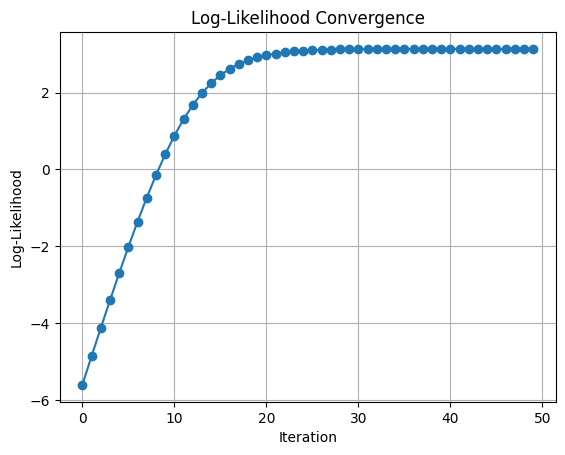

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Dataset: moderate variance, one missing value
X = np.array([
    [3.0, 4.0, 5.0],
    [4.2, 2.8, np.nan],  # Missing value here
    [2.7, 4.5, 6.2],
    [3.4, 3.6, 4.1],
    [2.9, 3.8, 5.3]
])

# === Initial Imputation ===
col_means = np.nanmean(X, axis=0)
inds = np.where(np.isnan(X))
X[inds] = np.take(col_means, inds[1])

# Initial mean and covariance
mu = np.mean(X, axis=0)
sigma = np.cov(X, rowvar=False)

max_iter = 100
tol = 1e-5
prev_ll = -np.inf
reg_val = 1e-5

log_likelihoods = []  # To store log-likelihoods for plotting

def regularize_cov_matrix(sigma, reg_val):
    return sigma + reg_val * np.eye(sigma.shape[0])

for i in range(max_iter):
    # === E-Step ===
    x_obs = X[1, :2]
    mu_o = mu[:2]
    mu_m = mu[2]
    sigma_oo = sigma[:2, :2]
    sigma_mo = sigma[2, :2]

    sigma_oo_reg = regularize_cov_matrix(sigma_oo, reg_val)
    sigma_oo_inv = np.linalg.inv(sigma_oo_reg)

    x_miss = mu_m + sigma_mo @ sigma_oo_inv @ (x_obs - mu_o)
    X[1, 2] = x_miss

    # === M-Step ===
    mu = np.mean(X, axis=0)
    sigma = np.cov(X.T)
    sigma_reg = regularize_cov_matrix(sigma, reg_val)

    # === Log-likelihood ===
    ll = np.sum([multivariate_normal.logpdf(x, mean=mu, cov=sigma_reg) for x in X])
    log_likelihoods.append(ll)
    ll_change = np.abs(ll - prev_ll)

    # Print progress
    if (i + 1) % 5 == 0 or ll_change < tol:
        variances = np.diag(sigma)
        print(f"Iteration {i + 1}")
        print(f"  Imputed X[1, 2]: {x_miss:.4f}")
        print(f"  Log-likelihood: {ll:.6f} (Δ = {ll_change:.6f})")
        print(f"  Mean vector: {mu}")
        print(f"  Variances: {variances}")
        print("-" * 40)

    if ll_change < tol:
        print(f"Converged at iteration {i + 1}")
        break

    prev_ll = ll

# === Final Output ===
print("\n=== Final Output ===")
print("Final mean vector:", mu)
print("Final covariance matrix:\n", sigma)
print("Imputed data matrix:\n", X)

# === Log-Likelihood Plot ===
plt.plot(log_likelihoods, marker='o')
plt.title("Log-Likelihood Convergence")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.show()


In [ ]:
np.isnan(X)

array([[False, False, False],
       [False, False,  True],
       [False, False, False],
       [False, False, False]])

In [ ]:
np.eye(sigma.shape[0])*np.array([[2,2,2],[2,2,2],[2,2,2]])


array([[2., 0., 0.],
       [0., 2., 0.],
       [0., 0., 2.]])